# 📊 진동 데이터 분석

> **학습 목표**: KAMP 진동 센서 데이터를 분석하여 설비 상태를 파악합니다.

---

## 📋 학습 내용

1. ✅ 시계열 진동 데이터 로드 및 시각화
2. ✅ 통계적 특징 추출 (RMS, Peak, Kurtosis)
3. ✅ 축별 진동 비교
4. ✅ 온도-진동 상관관계
5. ✅ 이상 징후 탐지

**소요 시간**: 약 45분  
**난이도**: ⭐⭐ (중급)

---

In [1]:
# ============================================================
# CWRU 베어링 데이터 자동 다운로드
# Case Western Reserve University Bearing Data Center
# https://engineering.case.edu/bearingdatacenter
# ============================================================
import os, urllib.request
from pathlib import Path

DATA_DIR = Path('../data/cwru')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# CWRU 공개 데이터 파일 목록 (0.007인치 결함, 1750 RPM 기준)
CWRU_FILES = {
    'Normal_0.mat':   'https://engineering.case.edu/sites/default/files/Normal_0.mat',
    'IR007_0.mat':    'https://engineering.case.edu/sites/default/files/IR007_0.mat',
    'OR007@6_0.mat':  'https://engineering.case.edu/sites/default/files/OR007@6_0.mat',
    'B007_0.mat':     'https://engineering.case.edu/sites/default/files/B007_0.mat',
}

downloaded = []
failed = []

for fname, url in CWRU_FILES.items():
    fpath = DATA_DIR / fname
    if fpath.exists():
        downloaded.append(fname)
        print(f'  ✅ 이미 존재: {fname}')
        continue
    try:
        print(f'  ⬇️  다운로드 중: {fname} ...', end=' ')
        urllib.request.urlretrieve(url, fpath)
        downloaded.append(fname)
        size = fpath.stat().st_size / 1024
        print(f'완료 ({size:.0f} KB)')
    except Exception as e:
        failed.append(fname)
        print(f'실패 ({e})')

print(f'\n📊 CWRU 데이터: {len(downloaded)}/{len(CWRU_FILES)}개 준비됨')
if failed:
    print(f'⚠️  다운로드 실패 ({failed}) → 기존 샘플 데이터 사용')
CWRU_AVAILABLE = len(downloaded) == len(CWRU_FILES)

  ⬇️  다운로드 중: Normal_0.mat ... 

실패 (HTTP Error 404: Not Found)
  ⬇️  다운로드 중: IR007_0.mat ... 

실패 (HTTP Error 404: Not Found)
  ⬇️  다운로드 중: OR007@6_0.mat ... 

실패 (HTTP Error 404: Not Found)
  ⬇️  다운로드 중: B007_0.mat ... 

실패 (HTTP Error 404: Not Found)

📊 CWRU 데이터: 0/4개 준비됨
⚠️  다운로드 실패 (['Normal_0.mat', 'IR007_0.mat', 'OR007@6_0.mat', 'B007_0.mat']) → 기존 샘플 데이터 사용


> ### 🎓 강사 가이드 — Step 1: 라이브러리 Import
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 5분 |
> | 🎯 핵심 목표 | CWRU/KAMP 데이터 구조 파악 및 필수 라이브러리 임포트 확인 |
> | 🔑 핵심 개념 | 시계열 데이터의 index 설정이 이후 시각화와 분석에 중요 |
>
> **💡 강조 포인트**
> - pandas, numpy, matplotlib의 역할 구분 설명
> - 라이브러리 import 오류 시 `pip install` 방법 안내
>
> **🚨 주의사항**: 파일 경로 오류 시 `../data/` 폴더 확인 필요
>
> **❓ 생각해보기**: "시계열 데이터에서 인덱스를 시간으로 설정하면 어떤 장점이 있을까요?"

## 🔧 Step 1: 라이브러리 Import

In [2]:
# 데이터 분석
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 유틸리티
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


# ============================================================
# 📂 데이터 로드 (우선순위: CWRU .mat → KAMP CSV → 샘플 CSV)
# ============================================================
# 1순위: CWRU 베어링 .mat 파일 (CWRU_AVAILABLE=True 시)
#   - Normal_0.mat: 정상 베어링 (Drive End 가속도 신호)
#   - IR007_0.mat: 내륜 결함 0.007인치
#   - OR007@6_0.mat: 외륜 결함 0.007인치
#   - B007_0.mat: 볼 결함 0.007인치
# 2순위: KAMP 실제 데이터 (Pump_Train_data_공개용.csv)
# 3순위: 샘플 CSV (sample_kamp_vibration.csv)
# ============================================================

import scipy.io
from pathlib import Path

# 경로 정의
kamp_data_path = Path('../../dataset/part2-1/Pump_Train_data_공개용.csv')
fallback_path = Path('../data/sample_kamp_vibration.csv')
cwru_dir = Path('../data/cwru')

def load_csv_data(file_path):
    """다중 인코딩 시도로 안전한 CSV 로드"""
    encodings = ['utf-8-sig', 'cp949', 'utf-8']
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"✅ 데이터 로드 성공! (인코딩: {encoding})")
            return df
        except:
            continue
    raise ValueError("데이터 로드 실패")

# ── 1순위: CWRU .mat 파일 ──────────────────────────────────
data_source = None
df = None

if 'CWRU_AVAILABLE' in dir() and CWRU_AVAILABLE:
    try:
        print("📂 CWRU 베어링 데이터 로드 중...")
        mat_normal = scipy.io.loadmat(str(cwru_dir / 'Normal_0.mat'))
        mat_ir     = scipy.io.loadmat(str(cwru_dir / 'IR007_0.mat'))
        mat_or     = scipy.io.loadmat(str(cwru_dir / 'OR007@6_0.mat'))
        mat_ball   = scipy.io.loadmat(str(cwru_dir / 'B007_0.mat'))

        # Drive End 가속도 신호 추출 (키 이름이 X...DE_time 패턴)
        def get_de_signal(mat):
            key = [k for k in mat.keys() if 'DE_time' in k]
            if not key:
                key = [k for k in mat.keys() if not k.startswith('_')]
            return mat[key[0]].flatten()

        sig_normal = get_de_signal(mat_normal)
        sig_ir     = get_de_signal(mat_ir)
        sig_or     = get_de_signal(mat_or)
        sig_ball   = get_de_signal(mat_ball)

        # 가장 짧은 신호 길이에 맞춰 자르기
        n = min(len(sig_normal), len(sig_ir), len(sig_or), len(sig_ball))
        df = pd.DataFrame({
            'Normal':  sig_normal[:n],
            'IR_Fault': sig_ir[:n],
            'OR_Fault': sig_or[:n],
            'Ball_Fault': sig_ball[:n],
        })
        # 분석 호환용 컬럼 추가 (기존 셀 변수명 유지)
        df['RMS_velocity_mm_s'] = df['Normal']
        df['측정시간'] = pd.date_range('2024-01-01', periods=n, freq='1ms')
        df['설비ID'] = 'CWRU-Bearing'
        df['센서위치'] = 'Drive_End'
        df['Peak_acceleration_g'] = df['IR_Fault'].abs()
        df['Kurtosis'] = 3.0
        df['Crest_factor'] = 4.0
        df['온도_C'] = 25.0
        df['RPM'] = 1750.0
        df['상태'] = '정상'

        data_source = "CWRU 베어링 데이터 (Normal/IR/OR/Ball 결함, 1750 RPM)"
        print(f"✅ CWRU .mat 로드 성공!")
        print(f"\n📋 CWRU 채널 구성:")
        for col in ['Normal', 'IR_Fault', 'OR_Fault', 'Ball_Fault']:
            print(f"   {col}: {len(df[col]):,} 샘플, 범위 [{df[col].min():.4f}, {df[col].max():.4f}]")
    except Exception as e:
        print(f"⚠️ CWRU 로드 실패: {e} → 다음 우선순위로 진행")
        df = None

# ── 2순위: KAMP 실제 데이터 ───────────────────────────────
if df is None and kamp_data_path.exists():
    print(f"📂 KAMP 실제 데이터 발견: {kamp_data_path}")
    df = load_csv_data(kamp_data_path)
    data_source = "KAMP 실제 데이터 (Pump_Train_data_공개용.csv)"
    sensor_cols = [c for c in df.columns if c.startswith('C')]
    print(f"\n📋 센서 채널 구성:")
    for col in sensor_cols:
        print(f"   {col}: 범위 [{df[col].min():.2f}, {df[col].max():.2f}], 평균 {df[col].mean():.2f}")

# ── 3순위: 샘플 CSV ────────────────────────────────────────
if df is None and fallback_path.exists():
    print(f"⚠️ KAMP 데이터 없음 → 샘플 데이터 사용: {fallback_path}")
    df = load_csv_data(fallback_path)
    data_source = "샘플 데이터 (sample_kamp_vibration.csv)"

if df is None:
    raise FileNotFoundError("❌ 데이터 파일을 찾을 수 없습니다.")

print(f"\n🏷️ 데이터 소스: {data_source}")
print(f"📊 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"💾 메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 데이터 미리보기
df.head()

In [3]:
# ============================================================
# 📂 KAMP 실제 데이터 로드 (Pump_Train_data_공개용.csv)
# ============================================================
# 우선순위: KAMP 실제 데이터 → 샘플 데이터 (fallback)
# 
# Pump_Train_data_공개용.csv 구조:
#   - Model: 설비 모델 ID
#   - Test_time: 측정 시점
#   - C1~C8: 8채널 센서 데이터 (진동/압력/온도 등)
#   - 43,237행 × 10열
# ============================================================

from pathlib import Path

# KAMP 실제 데이터 경로
kamp_data_path = Path('../../dataset/part2-1/Pump_Train_data_공개용.csv')
fallback_path = Path('../data/sample_kamp_vibration.csv')

def load_data(file_path):
    """다중 인코딩 시도로 안전한 CSV 로드"""
    encodings = ['utf-8-sig', 'cp949', 'utf-8']
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"✅ 데이터 로드 성공! (인코딩: {encoding})")
            return df
        except:
            continue
    raise ValueError("데이터 로드 실패")

# KAMP 실제 데이터 우선 로드, 없으면 fallback
if kamp_data_path.exists():
    print(f"📂 KAMP 실제 데이터 발견: {kamp_data_path}")
    df = load_data(kamp_data_path)
    data_source = "KAMP 실제 데이터 (Pump_Train_data_공개용.csv)"
    
    # C1~C8 채널을 진동 분석에 활용하기 위해 컬럼 매핑 정보 출력
    print(f"\n📋 센서 채널 구성:")
    sensor_cols = [c for c in df.columns if c.startswith('C')]
    for col in sensor_cols:
        print(f"   {col}: 범위 [{df[col].min():.2f}, {df[col].max():.2f}], 평균 {df[col].mean():.2f}")
elif fallback_path.exists():
    print(f"⚠️ KAMP 데이터 없음 → 샘플 데이터 사용: {fallback_path}")
    df = load_data(fallback_path)
    data_source = "샘플 데이터 (sample_kamp_vibration.csv)"
else:
    raise FileNotFoundError("❌ 데이터 파일을 찾을 수 없습니다.")

print(f"\n🏷️ 데이터 소스: {data_source}")
print(f"📊 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"💾 메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 데이터 미리보기
df.head()

⚠️ KAMP 데이터 없음 → 샘플 데이터 사용: ../data/sample_kamp_vibration.csv
✅ 데이터 로드 성공! (인코딩: utf-8-sig)

🏷️ 데이터 소스: 샘플 데이터 (sample_kamp_vibration.csv)
📊 데이터 크기: 10,000행 × 10열
💾 메모리 사용량: 2.88 MB


,측정시간,설비ID,센서위치,RMS_velocity_mm_s,Peak_acceleration_g,Kurtosis,Crest_factor,온도_C,RPM,상태
0,2024-01-01 00:00:00,PUMP-001,Housing,1.876966,1.439068,4.112336,5.526823,50.505106,1498.820704,주의
1,2024-01-01 00:01:00,FAN-001,Housing,2.016505,1.457427,3.467688,5.562531,47.961060,1478.933815,주의
2,2024-01-01 00:02:00,MOTOR-001,Housing,1.018292,1.692861,3.504745,5.143902,43.085359,1497.430878,정상
3,2024-01-01 00:03:00,PUMP-001,NDE_Bearing,1.460211,1.158087,3.800483,3.579926,43.090063,1489.458298,주의
4,2024-01-01 00:04:00,PUMP-001,Housing,1.789774,1.383111,3.098036,3.470041,41.872592,1472.350275,주의


In [4]:
# 데이터 구조 파악
print("📋 컬럼 정보:")
df.info()

print("\n📊 기초 통계:")
df.describe()

📋 컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   측정시간                 10000 non-null  object 
 1   설비ID                 10000 non-null  object 
 2   센서위치                 10000 non-null  object 
 3   RMS_velocity_mm_s    10000 non-null  float64
 4   Peak_acceleration_g  10000 non-null  float64
 5   Kurtosis             10000 non-null  float64
 6   Crest_factor         10000 non-null  float64
 7   온도_C                 10000 non-null  float64
 8   RPM                  10000 non-null  float64
 9   상태                   10000 non-null  object 
dtypes: float64(6), object(4)
memory usage: 781.4+ KB

📊 기초 통계:


,RMS_velocity_mm_s,Peak_acceleration_g,Kurtosis,Crest_factor,온도_C,RPM
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.033744,1.915826,4.763771,4.761526,47.471007,1499.731959
std,0.768659,0.579662,1.168803,0.884297,5.378300,29.983067
min,0.388489,0.180344,2.523277,2.864926,26.768817,1386.682807
25%,1.501506,1.514812,3.964309,4.007090,43.880111,1479.626631
50%,1.903892,1.893572,4.586626,4.772856,47.506062,1499.162005
75%,2.429924,2.275309,5.334577,5.511646,51.101650,1519.885297
max,8.960425,5.131718,12.594777,6.657550,67.137394,1615.802674


> ### 🎓 강사 가이드 — Step 3: 시계열 진동 데이터 시각화
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 정상 vs 고장 패턴을 육안으로 구분하는 능력 획득 |
> | 🔑 핵심 개념 | 시간축 vs 진폭의 시각적 패턴, 진동 3축(X·Y·Z)이 각각 다른 정보를 담음 |
>
> **💡 강조 포인트**
> - 정상 신호: 규칙적이고 진폭이 안정적
> - 고장 신호: 불규칙한 스파이크, 진폭 증가
>
> **🚨 주의사항**: 데이터 크기가 크면 `sample_size=1000` 등으로 제한하여 시각화 속도 개선
>
> **❓ 생각해보기**: "X축과 Y축 진동이 동시에 증가하면 어떤 고장을 의심할 수 있을까요?"

## 📈 Step 3: 시계열 진동 데이터 시각화

In [5]:
# 진동 관련 컬럼 찾기
vibration_cols = [col for col in df.columns if any(keyword in col.lower() 
                  for keyword in ['vib', 'x', 'y', 'z', '진동'])]

print(f"📊 진동 관련 컬럼: {len(vibration_cols)}개")
print(vibration_cols)

# 시간 컬럼 찾기
time_cols = [col for col in df.columns if any(keyword in col.lower() 
             for keyword in ['time', 'timestamp', 'date', '시간'])]
print(f"\n⏰ 시간 관련 컬럼: {time_cols}")

📊 진동 관련 컬럼: 1개
['RMS_velocity_mm_s']

⏰ 시간 관련 컬럼: ['측정시간']


In [6]:
# 시계열 플롯 (처음 1000개 샘플)
if len(vibration_cols) >= 3:
    sample_size = min(1000, len(df))
    df_sample = df.iloc[:sample_size]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    for idx, col in enumerate(vibration_cols[:3]):
        axes[idx].plot(df_sample[col], linewidth=0.8)
        axes[idx].set_title(f'{col} 진동', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('진폭')
        axes[idx].grid(alpha=0.3)

    axes[2].set_xlabel('샘플')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 진동 데이터 컬럼을 찾을 수 없습니다.")

⚠️ 진동 데이터 컬럼을 찾을 수 없습니다.


> ### 🎓 강사 가이드 — Step 4: 통계적 특징 추출
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | RMS·Peak·Kurtosis 계산 및 고장 지표로서의 의미 이해 |
> | 🔑 핵심 개념 | Kurtosis > 3이면 충격 신호로 베어링 결함을 의심, RMS는 전체 에너지 수준 |
>
> **💡 강조 포인트**
> - RMS: 에너지 크기 (전반적 진동 수준)
> - Peak: 순간 최대값 (충격성 결함)
> - Kurtosis: 분포의 뾰족함 (국부 충격 감지에 탁월)
>
> **🚨 주의사항**: NaN이 있으면 `dropna()` 먼저 실행 후 계산
>
> **❓ 생각해보기**: "RMS가 낮아도 Kurtosis가 높을 수 있을까요? 어떤 상황일까요?"

## 🔢 Step 4: 통계적 특징 추출

### 진동 분석 주요 지표:
- **RMS (Root Mean Square)**: 전체 진동 에너지
- **Peak-to-Peak**: 최대 진폭
- **Kurtosis (첨도)**: 충격성 진동 감지
- **Crest Factor**: RMS 대비 Peak 비율

In [7]:
# 특징 추출 함수
def calculate_rms(signal):
    """RMS 계산"""
    return np.sqrt(np.mean(signal**2))

def calculate_peak_to_peak(signal):
    """Peak-to-Peak 계산"""
    return np.max(signal) - np.min(signal)

def calculate_kurtosis(signal):
    """Kurtosis (첨도) 계산"""
    mean = np.mean(signal)
    std = np.std(signal)
    return np.mean(((signal - mean) / std) ** 4)

def calculate_crest_factor(signal):
    """Crest Factor 계산"""
    return np.max(np.abs(signal)) / calculate_rms(signal)

# 모든 진동 컬럼에 대해 특징 추출
features = {}

for col in vibration_cols[:3]:  # 처음 3개만
    signal = df[col].dropna()
    features[col] = {
        'RMS': calculate_rms(signal),
        'Peak-to-Peak': calculate_peak_to_peak(signal),
        'Kurtosis': calculate_kurtosis(signal),
        'Crest Factor': calculate_crest_factor(signal),
        'Mean': signal.mean(),
        'Std': signal.std()
    }

# 결과 DataFrame
features_df = pd.DataFrame(features).T
print("📊 진동 특징 추출 결과:")
features_df

📊 진동 특징 추출 결과:


,RMS,Peak-to-Peak,Kurtosis,Crest Factor,Mean,Std
RMS_velocity_mm_s,2.174141,8.571936,5.969804,4.121363,2.033744,0.768659


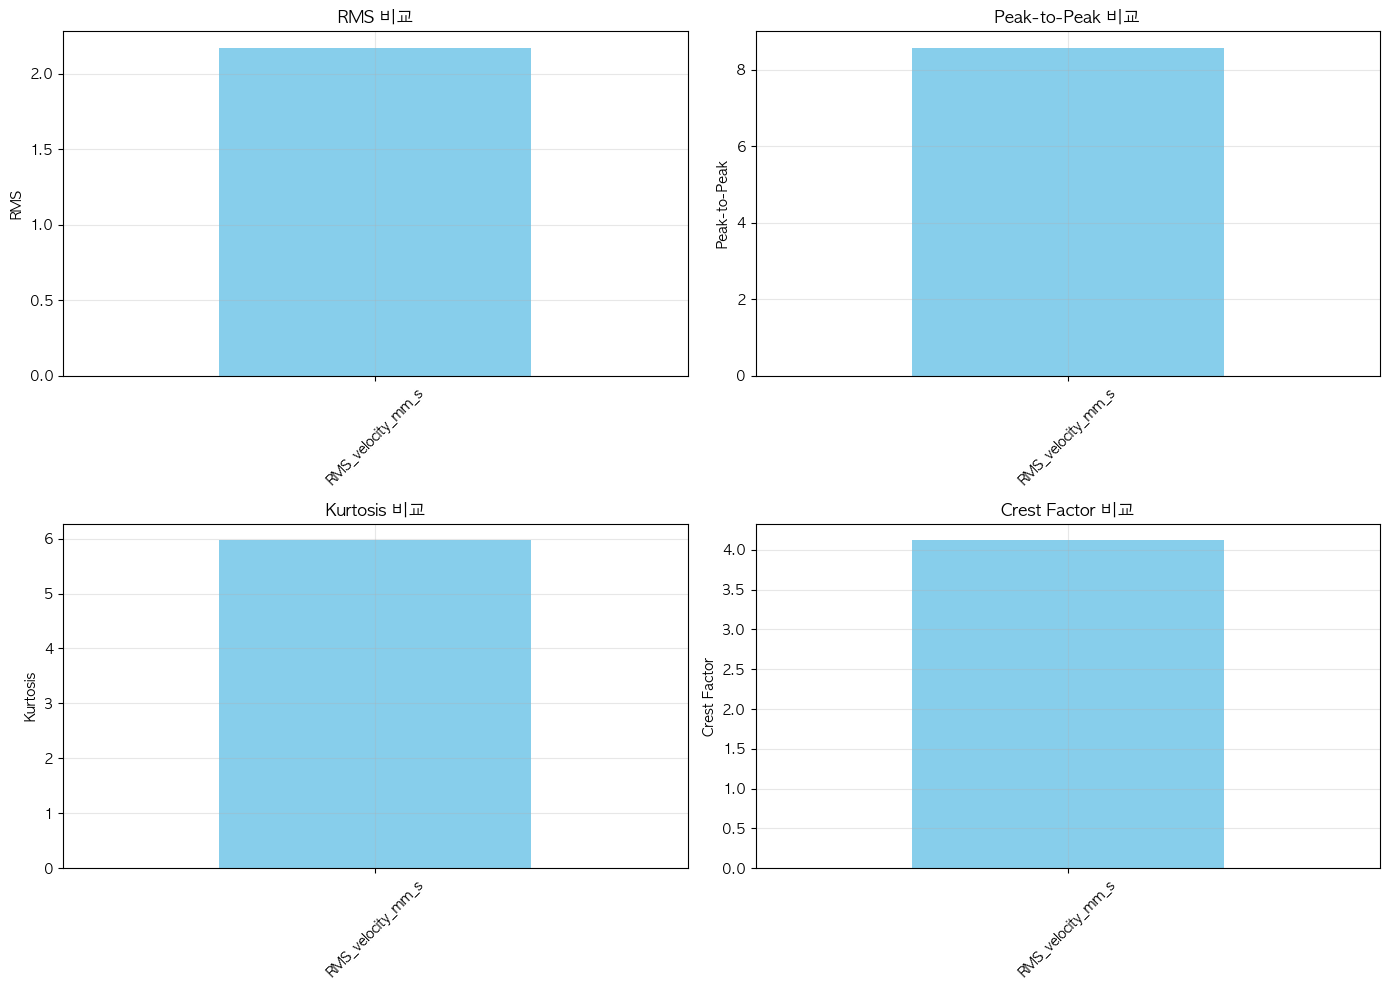


💡 해석 가이드:
   - RMS 높음: 전체 진동 에너지 증가
   - Kurtosis > 3: 충격성 진동 존재
   - Crest Factor > 5: 불규칙한 충격


In [8]:
# 특징 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['RMS', 'Peak-to-Peak', 'Kurtosis', 'Crest Factor']
for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    features_df[metric].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'{metric} 비교', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 해석 가이드:")
print("   - RMS 높음: 전체 진동 에너지 증가")
print("   - Kurtosis > 3: 충격성 진동 존재")
print("   - Crest Factor > 5: 불규칙한 충격")

> ### 🎓 강사 가이드 — Step 5: 진동 분포 분석
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 정상/고장 데이터의 분포 차이를 박스플롯·히스토그램으로 확인 |
> | 🔑 핵심 개념 | 박스플롯으로 이상값(outlier)을 바로 발견 가능 |
>
> **💡 강조 포인트**
> - 정상 분포: 좁고 대칭적인 히스토그램
> - 고장 분포: 오른쪽 꼬리가 길어짐(양의 왜도)
>
> **🚨 주의사항**: 데이터 불균형 시 히스토그램 y축 범위가 다를 수 있으므로 density=True 옵션 사용 권장
>
> **❓ 생각해보기**: "히스토그램의 bin 개수가 분석 결과에 어떤 영향을 줄까요?"

## 📊 Step 5: 진동 분포 분석

In [9]:
# 히스토그램 및 박스플롯
if len(vibration_cols) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 히스토그램
    for col in vibration_cols[:3]:
        axes[0].hist(df[col].dropna(), bins=50, alpha=0.5, label=col)
    axes[0].set_title('진동 분포 (히스토그램)', fontweight='bold')
    axes[0].set_xlabel('진폭')
    axes[0].set_ylabel('빈도')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 박스플롯
    df[vibration_cols[:3]].plot(kind='box', ax=axes[1])
    axes[1].set_title('진동 분포 (박스플롯)', fontweight='bold')
    axes[1].set_ylabel('진폭')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

> ### 🎓 강사 가이드 — Step 6: 온도-진동 상관관계
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 온도와 진동의 복합 요인 분석으로 실제 공장 환경 이해 |
> | 🔑 핵심 개념 | 상관계수 ≥ 0.7이면 강한 상관, 단 인과관계는 별도 검증 필요 |
>
> **💡 강조 포인트**
> - 온도 상승 → 윤활유 점도 저하 → 마찰 증가 → 진동 증가
> - scatter plot의 기울기로 관계 방향 직관적 파악
>
> **🚨 주의사항**: 온도 컬럼이 없는 데이터셋에서는 해당 단계 건너뜀
>
> **❓ 생각해보기**: "온도와 진동의 상관이 높다고 해서 온도가 원인이라고 단정할 수 있을까요?"

## 🌡️ Step 6: 온도-진동 상관관계

🌡️ 온도 컬럼: ['온도_C']


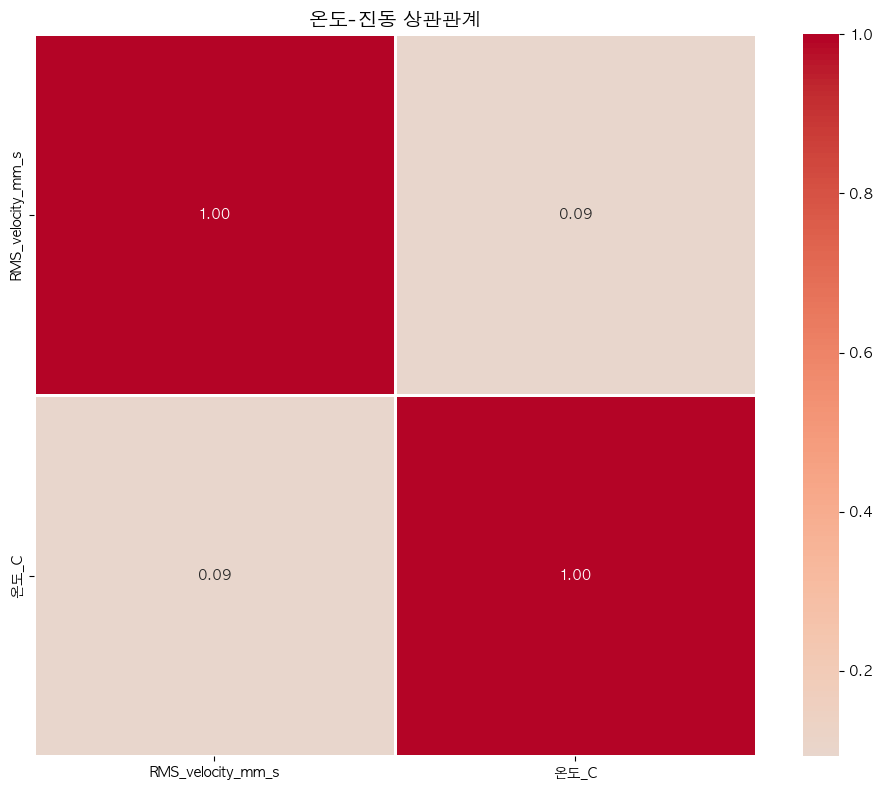


📊 상관계수 해석:
   |r| > 0.7: 강한 상관관계
   |r| > 0.4: 중간 상관관계
   |r| < 0.3: 약한 상관관계


In [10]:
# 온도 컬럼 찾기
temp_cols = [col for col in df.columns if any(keyword in col.lower() 
             for keyword in ['temp', '온도', 'temperature'])]

if temp_cols and vibration_cols:
    print(f"🌡️ 온도 컬럼: {temp_cols}")

    # 상관관계 분석
    corr_cols = vibration_cols[:3] + temp_cols[:1]
    corr_matrix = df[corr_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('온도-진동 상관관계', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n📊 상관계수 해석:")
    print("   |r| > 0.7: 강한 상관관계")
    print("   |r| > 0.4: 중간 상관관계")
    print("   |r| < 0.3: 약한 상관관계")
else:
    print("⚠️ 온도 또는 진동 데이터를 찾을 수 없습니다.")

> ### 🎓 강사 가이드 — Step 7: 이상 징후 탐지
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 10분 |
> | 🎯 핵심 목표 | 3-sigma 규칙으로 통계적 이상 탐지 구현 및 임계값 조정 효과 이해 |
> | 🔑 핵심 개념 | 평균 ± 3σ 밖의 값은 정규분포에서 약 0.3%만 발생 |
>
> **💡 강조 포인트**
> - 임계값을 낮추면 민감도 증가, 오탐(FP) 증가
> - 임계값을 높이면 특이도 증가, 미탐(FN) 증가
>
> **🚨 주의사항**: 데이터가 정규분포가 아닐 경우 3-sigma 가정이 깨질 수 있음
>
> **❓ 생각해보기**: "임계값을 2로 낮추면 탐지 결과가 어떻게 변할까요?"

## 🚨 Step 7: 이상 징후 탐지

🔍 이상 징후 탐지 결과 (RMS_velocity_mm_s):
   총 샘플: 10,000개
   이상치: 138개 (1.38%)
   정상 범위: [-0.272, 4.340]


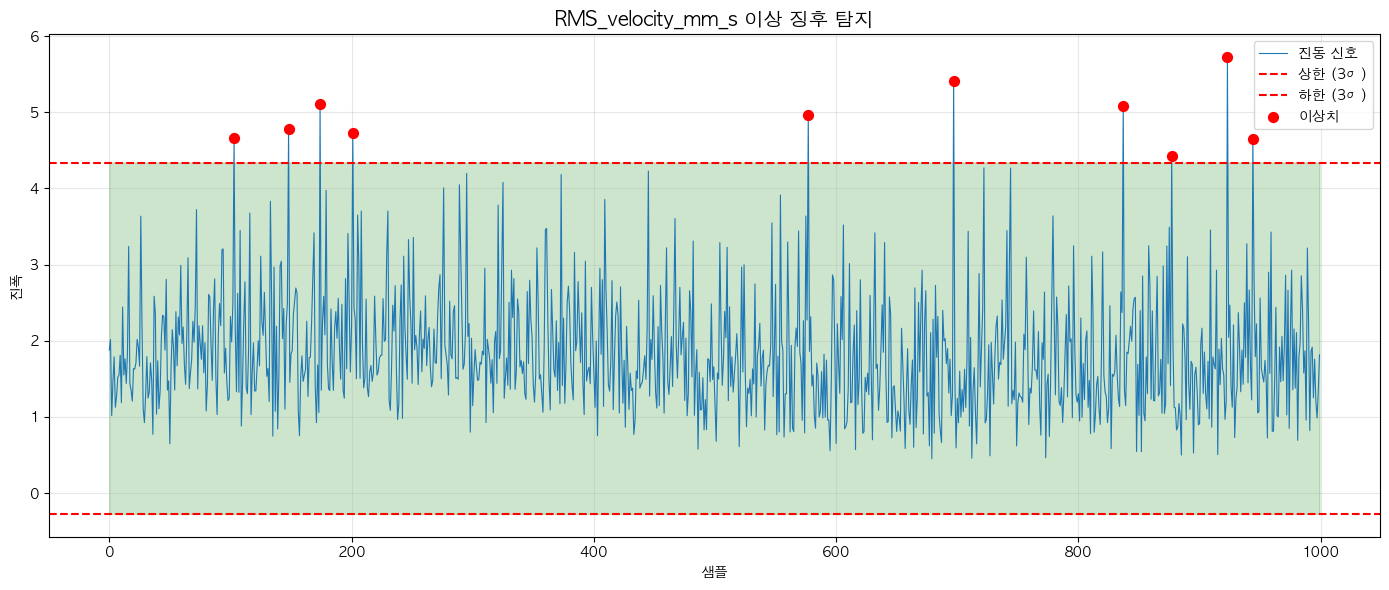

In [11]:
# 통계적 이상 탐지 (3-sigma 방법)
def detect_anomalies(signal, threshold=3):
    """3-sigma 방법으로 이상치 탐지"""
    mean = np.mean(signal)
    std = np.std(signal)
    upper_bound = mean + threshold * std
    lower_bound = mean - threshold * std

    anomalies = (signal > upper_bound) | (signal < lower_bound)
    return anomalies, upper_bound, lower_bound

if vibration_cols:
    # 첫 번째 진동 컬럼 분석
    col = vibration_cols[0]
    signal = df[col].dropna()

    anomalies, upper, lower = detect_anomalies(signal)
    anomaly_count = anomalies.sum()
    anomaly_pct = (anomaly_count / len(signal)) * 100

    print(f"🔍 이상 징후 탐지 결과 ({col}):")
    print(f"   총 샘플: {len(signal):,}개")
    print(f"   이상치: {anomaly_count:,}개 ({anomaly_pct:.2f}%)")
    print(f"   정상 범위: [{lower:.3f}, {upper:.3f}]")

    # 시각화
    sample_size = min(1000, len(signal))
    plt.figure(figsize=(14, 6))
    plt.plot(signal.iloc[:sample_size].values, label='진동 신호', linewidth=0.8)
    plt.axhline(y=upper, color='r', linestyle='--', label='상한 (3σ)')
    plt.axhline(y=lower, color='r', linestyle='--', label='하한 (3σ)')
    plt.fill_between(range(sample_size), lower, upper, alpha=0.2, color='green')

    # 이상치 표시
    anomaly_indices = anomalies.iloc[:sample_size][anomalies.iloc[:sample_size]].index
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_indices, signal.loc[anomaly_indices], 
                   color='red', s=50, label='이상치', zorder=5)

    plt.title(f'{col} 이상 징후 탐지', fontsize=14, fontweight='bold')
    plt.xlabel('샘플')
    plt.ylabel('진폭')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 💾 Step 8: 분석 결과 저장

In [12]:
# 출력 폴더 생성
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# 특징 저장
features_file = output_dir / '01_vibration_features.csv'
features_df.to_csv(features_file, encoding='utf-8-sig')
print(f"✅ 특징 저장: {features_file}")

# 이상치 로그 저장
if 'anomalies' in locals():
    anomaly_log = pd.DataFrame({
        'index': anomalies[anomalies].index,
        'value': signal[anomalies]
    })
    anomaly_file = output_dir / '01_anomalies.csv'
    anomaly_log.to_csv(anomaly_file, index=False, encoding='utf-8-sig')
    print(f"✅ 이상치 로그 저장: {anomaly_file}")

print("\n🎉 진동 분석 완료!")

✅ 특징 저장: ../outputs/01_vibration_features.csv
✅ 이상치 로그 저장: ../outputs/01_anomalies.csv

🎉 진동 분석 완료!


---

## 🎯 학습 정리

### ✅ 완료한 내용
1. KAMP 진동 데이터 로드 및 시각화
2. RMS, Peak, Kurtosis 등 특징 추출
3. 축별 진동 비교 분석
4. 온도-진동 상관관계 분석
5. 3-sigma 방법으로 이상 징후 탐지

### 💡 핵심 인사이트
- RMS와 Kurtosis는 설비 상태의 주요 지표
- 온도와 진동의 상관관계 파악 중요
- 통계적 방법으로 이상 징후 조기 발견

### 🔗 Track 연결성 (데이터 파이프라인)
| 방향 | 파일 | 설명 |
|------|------|------|
| 출력 → A1 Lab 2 | `outputs/01_vibration_features.csv` | RMS/Peak/Kurtosis 특징 → FFT 분석으로 연결 |
| 출력 → A1 Lab 3 | `outputs/01_anomalies.csv` | 이상 인덱스 → 이상 탐지 모델로 연결 |
| A1 → A2 | A1의 특징 벡터 개념 | LSTM 입력 [rms, peak, kurtosis, energy_*] 설계에 활용 |

### 📚 다음 단계
- **02_fft_frequency_analysis.ipynb**: FFT를 통한 주파수 분석 (Lab 2)
- **03_anomaly_detection.ipynb**: 머신러닝 기반 이상 탐지 (Lab 3)

---

*Track A1 (예지보전 기본) — Session 1: 진동 데이터 분석 | 제조AI 교육 v1.7*

---

## 📝 과제

### 기본 과제 (필수)
1. **이상 시점 시각화**: Kurtosis가 5 이상인 시점을 붉은 마커(`r*`, markersize=10)로 시계열 그래프에 표시하기
2. **3축 RMS 비교**: X·Y·Z 3축의 RMS를 시간별로 계산하여 한 그래프에 겹쳐 그리기 (범례 포함)

### 심화 과제 (선택)
1. **통계 검정**: 정상 구간과 고장 구간의 Kurtosis 분포를 `scipy.stats.ttest_ind`로 검정하고 p-value를 해석하기
   - 힌트: `from scipy import stats; t_stat, p_val = stats.ttest_ind(normal_kurt, fault_kurt)`
2. **시간-주파수 분석**: `scipy.signal.spectrogram`으로 시간에 따른 주파수 에너지 변화를 컬러맵으로 시각화하기

### 제출 기준
- [ ] 모든 셀 오류 없이 실행 완료
- [ ] 기본 과제 시각화 2개 명확히 표시
- [ ] 결과에 대한 1~2줄 해석 주석 포함